In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import seaborn as sns
sns.set_style('darkgrid')

def bs_call(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European call option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Call option price
    """
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return S0*norm.cdf(d1)-K*np.exp(-r*t)*norm.cdf(d2)


def bs_put(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European put option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Put option price
    """
    
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return -S0*norm.cdf(-d1)+K*np.exp(-r*t)*norm.cdf(-d2)




## Option Price vs Time to Expiry

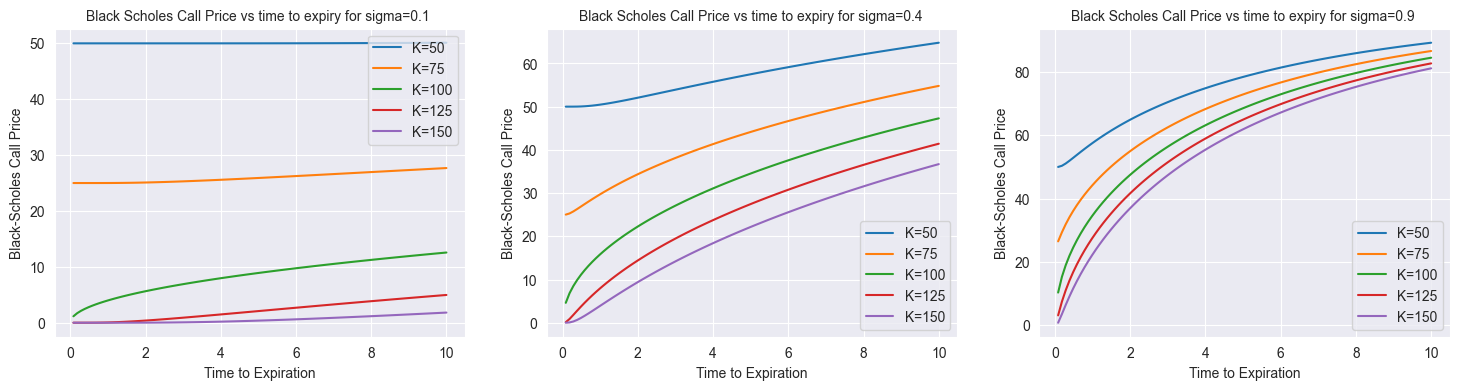

In [7]:
S0 = 100
K = [50,75,100,125,150]
sigma_list = [0.1, 0.4, 0.9]
times = np.linspace(1/12, 10, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [bs_call(S0,strike_price,sigma_list[i], t = times[j]) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Call Price')
    axes[i].set_title(f'Black Scholes Call Price vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()

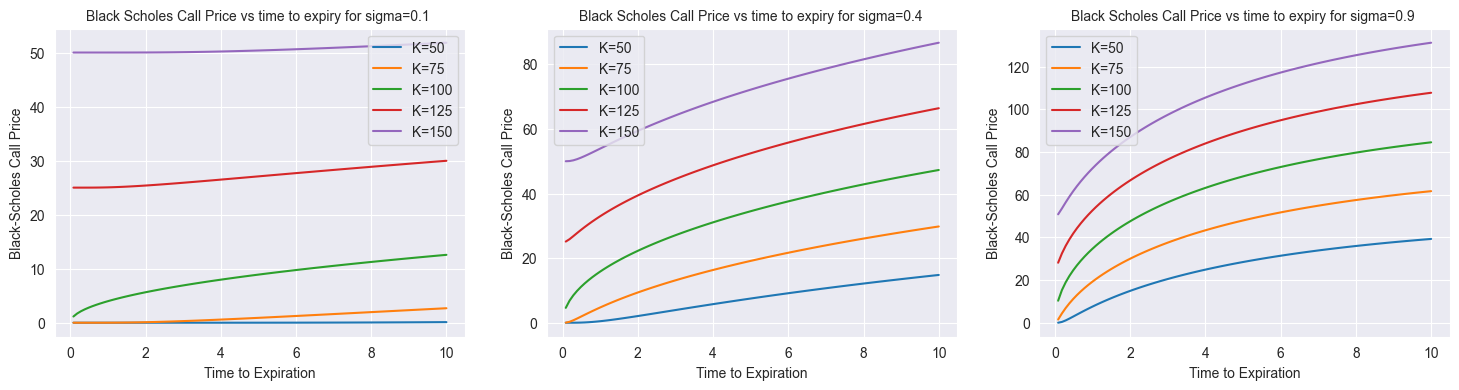

In [8]:
S0 = 100
K = [50,75,100,125,150]
sigma_list = [0.1, 0.4, 0.9]
times = np.linspace(1/12, 10, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [bs_put(S0,strike_price,sigma_list[i], t = times[j]) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Call Price')
    axes[i].set_title(f'Black Scholes Call Price vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()

## Delta vs time to expiry

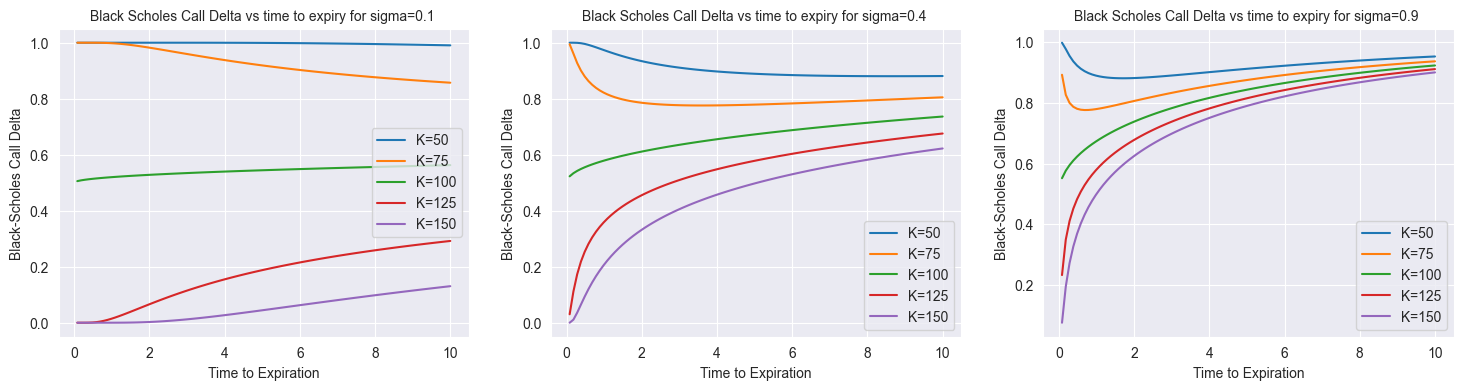

In [9]:
S0 = 100
K = [50,75,100,125,150]
sigma_list = [0.1, 0.4, 0.9]
times = np.linspace(1/12, 10, 100)
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [(bs_call(S0*(1+epsilon),strike_price,sigma_list[i], t = times[j]) - bs_call(S0*(1-epsilon),strike_price,sigma_list[i], t = times[j]))/(2*S0*epsilon) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Call Delta')
    axes[i].set_title(f'Black Scholes Call Delta vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()


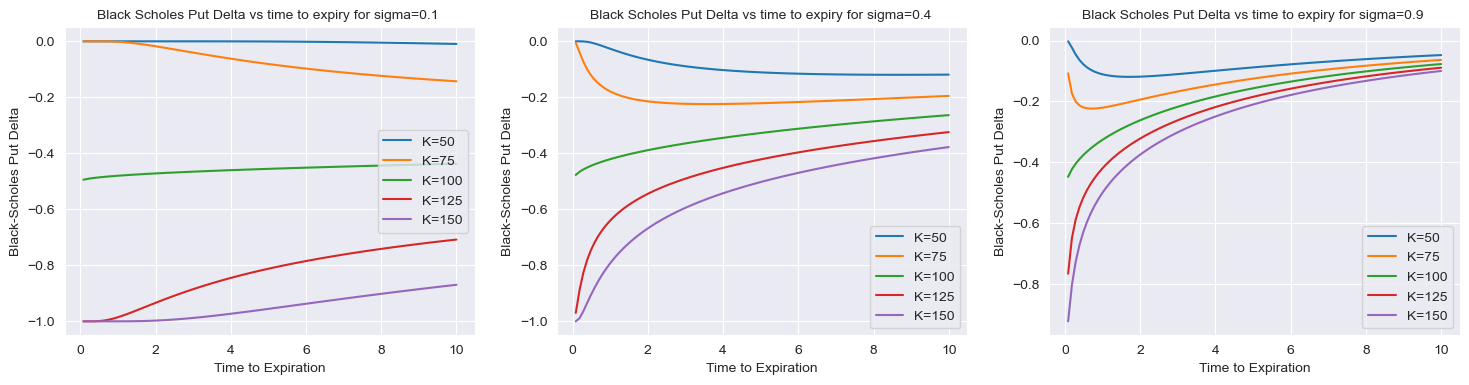

In [64]:
S0 = 100
K = [50,75,100,125,150]
sigma_list = [0.1, 0.4, 0.9]
times = np.linspace(1/12, 10, 100)
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i in range(len(sigma_list)):
    for strike_price in K:
        axes[i].plot(times, [(bs_put(S0*(1+epsilon),strike_price,sigma_list[i], t = times[j]) - bs_put(S0*(1-epsilon),strike_price,sigma_list[i], t = times[j]))/(2*S0*epsilon) for j in range(len(times))], label=f'K={strike_price}')
    axes[i].set_xlabel('Time to Expiration')
    axes[i].set_ylabel('Black-Scholes Put Delta')
    axes[i].set_title(f'Black Scholes Put Delta vs time to expiry for sigma={sigma_list[i]} ', size = 10)
    axes[i].legend()

plt.show()

## Delta vs Spot Prices

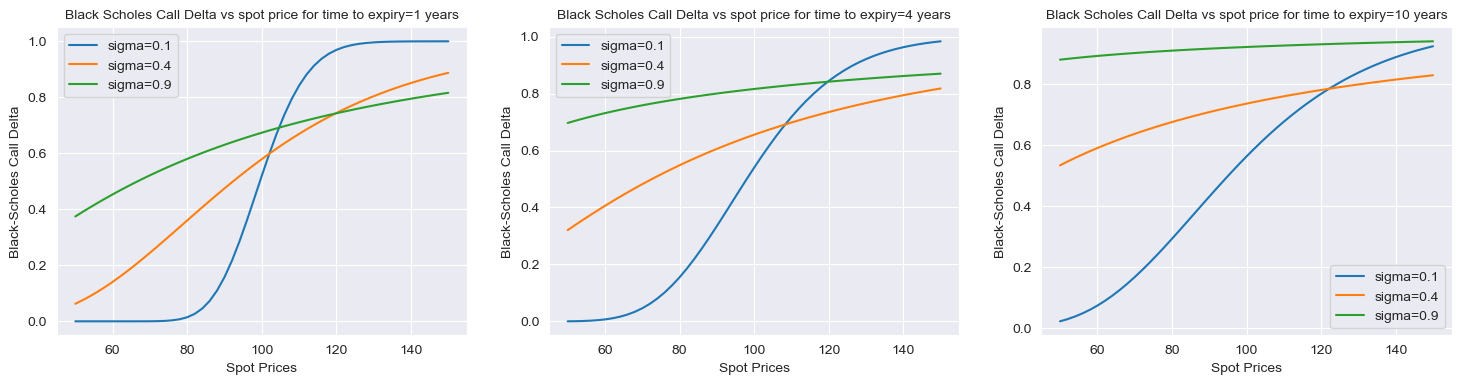

In [55]:
spot_prices = [i for i in range(50,151, 2)]
K = 100
sigma_list = [0.1, 0.4, 0.9]
times = [1,4,10]
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(times)):
    for sigma in sigma_list:
        axes[j].plot(spot_prices, [(bs_call(S*(1+epsilon),100,sigma, t = times[j]) - bs_call(S*(1-epsilon),100,sigma, t = times[j]))/(2*S*epsilon) for S in spot_prices], label=f'sigma={sigma}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes Call Delta')
    axes[j].set_title(f'Black Scholes Call Delta vs spot price for time to expiry={times[j]} years', size = 10)
    axes[j].legend()

plt.show()


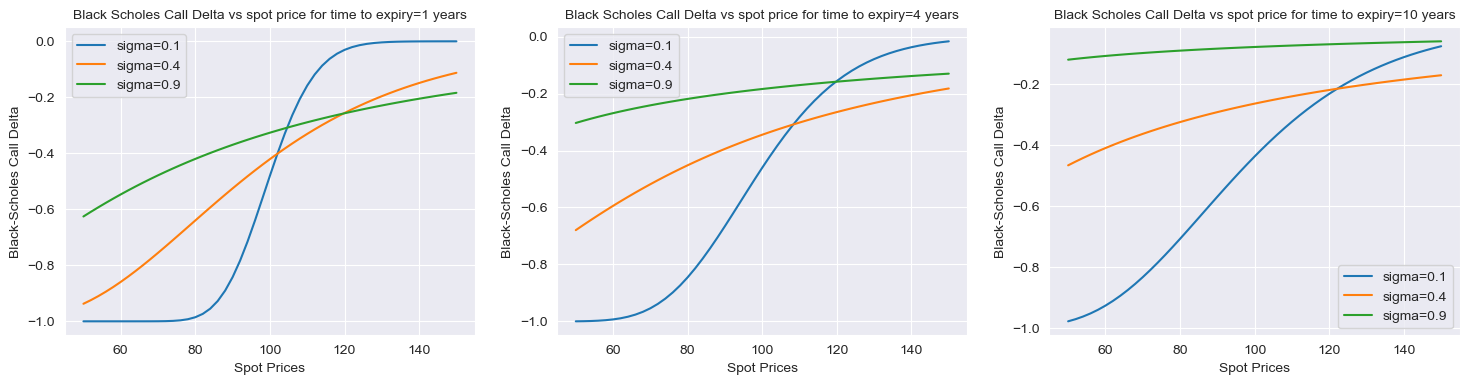

In [65]:
spot_prices = [i for i in range(50,151, 2)]
K = 100
sigma_list = [0.1, 0.4, 0.9]
times = [1,4,10]
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(times)):
    for sigma in sigma_list:
        axes[j].plot(spot_prices, [(bs_put(S*(1+epsilon),100,sigma, t = times[j]) - bs_put(S*(1-epsilon),100,sigma, t = times[j]))/(2*S*epsilon) for S in spot_prices], label=f'sigma={sigma}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes Call Delta')
    axes[j].set_title(f'Black Scholes Call Delta vs spot price for time to expiry={times[j]} years', size = 10)
    axes[j].legend()

plt.show()

## Time Derivative vs Spot Prices

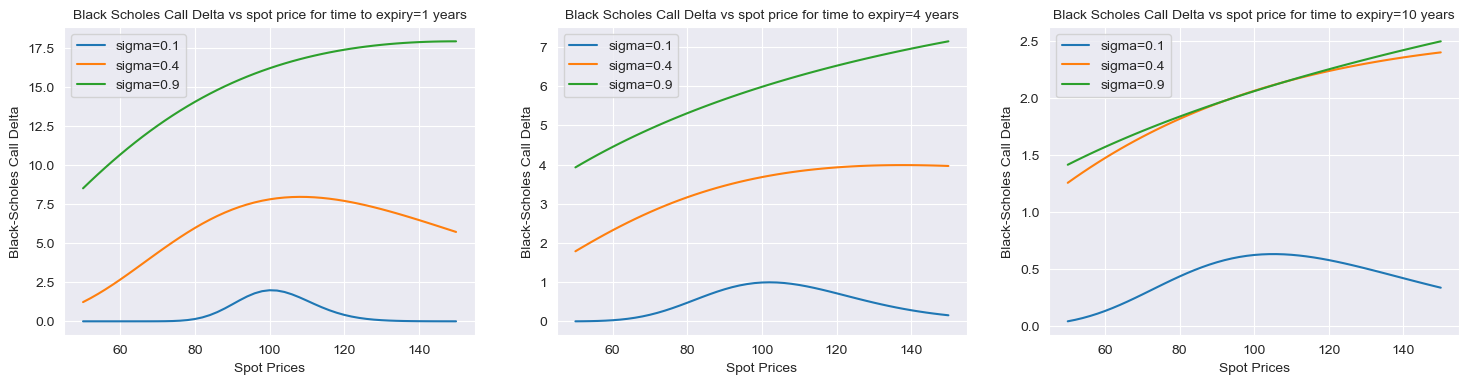

In [56]:
spot_prices = [i for i in range(50,151, 2)]
K = 100
sigma_list = [0.1, 0.4, 0.9]
times = [1,4,10]
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(times)):
    for sigma in sigma_list:
        axes[j].plot(spot_prices, [(bs_call(S,100,sigma, t = times[j]*(1+epsilon)) - bs_call(S,100,sigma, t = times[j]*(1-epsilon)))/(2*times[j]*epsilon) for S in spot_prices], label=f'sigma={sigma}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes Call Delta')
    axes[j].set_title(f'Black Scholes Call Delta vs spot price for time to expiry={times[j]} years', size = 10)
    axes[j].legend()

plt.show()

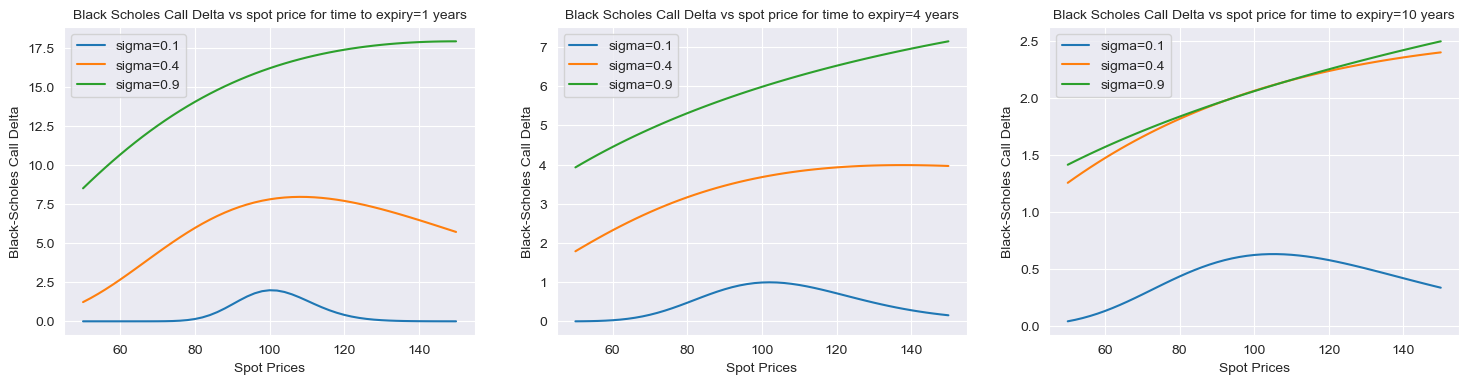

In [66]:
spot_prices = [i for i in range(50,151, 2)]
K = 100
sigma_list = [0.1, 0.4, 0.9]
times = [1,4,10]
epsilon=0.005

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for j in range(len(times)):
    for sigma in sigma_list:
        axes[j].plot(spot_prices, [(bs_put(S,100,sigma, t = times[j]*(1+epsilon)) - bs_put(S,100,sigma, t = times[j]*(1-epsilon)))/(2*times[j]*epsilon) for S in spot_prices], label=f'sigma={sigma}')
    axes[j].set_xlabel('Spot Prices')
    axes[j].set_ylabel('Black-Scholes Call Delta')
    axes[j].set_title(f'Black Scholes Call Delta vs spot price for time to expiry={times[j]} years', size = 10)
    axes[j].legend()

plt.show()